# Tutorial 2: Surface Codes and Lattice Surgery

How can we protect a logical qubit using checks that involve only nearby qubits?

In the [Shor-code tutorial](shor_tutorial.ipynb), we encoded one qubit into nine data qubits and decoded ideal syndrome measurements. Here we arrange nine data qubits on a **rotated surface-code patch**, inspect its local checks, and replace ideal checks with ancilla circuits. We then repeat those measurements under noise and decode the resulting history.

We assume familiarity with the Shor notebook's stabilizers, logical operators, syndrome bits, and Pauli frames. Run the cells in order; the examples build on one another.

We use **Stim** for circuits and sampling, and **PyMatching** for decoding repeated measurements. We first study ideal operations so that each result has a clear interpretation, then introduce noisy gates, preparation, and readout in the final memory experiment.

Finally, we join patches to measure a joint logical parity and use such measurements to implement a logical CNOT. An ideal seam example exposes the algebra; a Loom example compiles a complete lattice-surgery operation into physical circuits.

In [1]:
import stim
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from IPython.display import display, Markdown
from importlib.metadata import version

print("Versions:", {name: version(name) for name in ["stim", "pymatching", "numpy", "matplotlib"]})

Versions: {'stim': '1.16.0', 'pymatching': '2.4.0', 'numpy': '2.5.2', 'matplotlib': '3.11.1'}


## 1. A logical qubit on a patch

Number the data qubits by rows:

$$
\begin{matrix}0&1&2\\3&4&5\\6&7&8\end{matrix}.
$$

A rotated surface code uses weight-four checks in the interior and weight-two checks at the boundary. For the orientation used here, the generators are

$$
\begin{aligned}
S_{X,0}&=X_0X_1,&S_{Z,0}&=Z_0Z_1Z_3Z_4,\\
S_{X,1}&=X_1X_2X_4X_5,&S_{Z,1}&=Z_2Z_5,\\
S_{X,2}&=X_3X_4X_6X_7,&S_{Z,2}&=Z_3Z_6,\\
S_{X,3}&=X_7X_8,&S_{Z,3}&=Z_4Z_5Z_7Z_8.
\end{aligned}
$$

Every $X$ check overlaps every $Z$ check on zero or two data qubits. Each shared qubit contributes an anticommutation, so an even overlap makes the complete checks commute.

These eight independent constraints leave a two-dimensional code space: nine data qubits encode one logical qubit. Ancillas used to measure the checks are additional physical qubits.

In [2]:
x_supports = [(0, 1), (1, 2, 4, 5), (3, 4, 6, 7), (7, 8)]
z_supports = [(0, 1, 3, 4), (2, 5), (3, 6), (4, 5, 7, 8)]


def pauli_on(pauli, qubits):
    operator = stim.PauliString(9)
    for q in qubits:
        operator[q] = pauli
    return operator


stabilizers = {
    **{f"SX{i}": pauli_on("X", qs) for i, qs in enumerate(x_supports)},
    **{f"SZ{i}": pauli_on("Z", qs) for i, qs in enumerate(z_supports)},
}
checks = list(stabilizers.values())
assert all(a.commutes(b) for a in checks for b in checks)
for name, operator in stabilizers.items():
    print(f"{name}: {operator}")  # _ means identity.

SX0: +XX_______
SX1: +_XX_XX___
SX2: +___XX_XX_
SX3: +_______XX
SZ0: +ZZ_ZZ____
SZ1: +__Z__Z___
SZ2: +___Z__Z__
SZ3: +____ZZ_ZZ


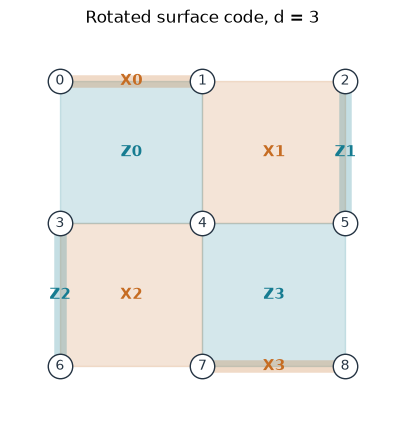

In [3]:
positions = {q: np.array([q % 3, q // 3]) for q in range(9)}


def draw_patch(ax, error=None, title="Rotated surface code, d = 3"):
    for kind, supports, color in [("X", x_supports, "#c66c22"),
                                  ("Z", z_supports, "#167c91")]:
        for i, support in enumerate(supports):
            points = np.array([positions[q] for q in support])
            center = points.mean(axis=0)
            if len(points) == 4:
                angles = np.arctan2(points[:, 1]-center[1], points[:, 0]-center[0])
                ax.add_patch(Polygon(points[np.argsort(angles)], color=color, alpha=0.18))
            else:
                ax.plot(points[:, 0], points[:, 1], color=color, lw=9, alpha=0.25)
            violated = error is not None and not error.commutes(stabilizers[f"S{kind}{i}"])
            ax.text(*center, f"{kind}{i}" + (" −" if violated else ""),
                    ha="center", va="center", color="crimson" if violated else color,
                    fontsize=11, weight="bold")
    for q, point in positions.items():
        marked = error is not None and error[q] != 0
        ax.scatter(*point, s=310, color="crimson" if marked else "white",
                   edgecolor="#253443", zorder=3)
        ax.text(*point, str(q), ha="center", va="center", zorder=4,
                color="white" if marked else "#253443")
    ax.set(xlim=(-0.35, 2.35), ylim=(2.35, -0.35), aspect="equal", title=title)
    ax.axis("off")


fig, ax = plt.subplots(figsize=(5, 5))
draw_patch(ax)
plt.show()

Colored regions and edges show **check supports**: which data qubits participate. The labels $X0,\ldots,Z3$ name checks, not additional data qubits. We will introduce their measurement ancillas below.

### Logical operators

For this orientation, choose

$$
\overline Z=Z_0Z_1Z_2,\qquad
\overline X=X_0X_3X_6.
$$

Each commutes with all eight checks, but the two logical operators anticommute because they overlap once. They therefore act as $Z$ and $X$ on the encoded qubit.

Multiplying a logical operator by a stabilizer gives an equivalent representative. For example,

$$
(Z_0Z_1Z_2)(Z_0Z_1Z_3Z_4)=Z_2Z_3Z_4.
$$

These two strings have the same action on every encoded state. The usual distance-three rotated patch has parameters $[[9,1,3]]$; its weight-three logical strings show why some errors can escape all the local checks. We will demonstrate such an error explicitly.

In [4]:
logical_z = pauli_on("Z", [0, 1, 2])
logical_x = pauli_on("X", [0, 3, 6])
assert all(logical_z.commutes(s) and logical_x.commutes(s) for s in checks)
assert not logical_z.commutes(logical_x)
print("Logical Z:", logical_z)
print("Logical X:", logical_x)
print("Equivalent logical Z:", logical_z * stabilizers["SZ0"])

Logical Z: +ZZZ______
Logical X: +X__X__X__
Equivalent logical Z: +__ZZZ____


## 2. Preparing logical states

The checks specify the code space, but they do not specify which logical state it contains. To select $|0_L\rangle$, also require $\overline Z=+1$; to select $|1_L\rangle$, require $\overline Z=-1$. Similarly, $|+_L\rangle$ and $|-_L\rangle$ have logical $X$ signs $+1$ and $-1$.

Stim can construct these states from their nine independent stabilizers. `from_stabilizers` finds a Clifford circuit that prepares the specified state from all-zero input. This is an **ideal preparation for our algebra examples**; the synthesized gates need not respect the patch's nearest-neighbor layout. The later memory circuit uses local check measurements instead.

In [5]:
def prepare_surface(state="0"):
    if state not in ("0", "1", "+", "-"):
        raise ValueError("Choose '0', '1', '+', or '-'.")
    logical = logical_z if state in ("0", "1") else logical_x
    sign = -1 if state in ("1", "-") else 1
    tableau = stim.Tableau.from_stabilizers(checks + [sign * logical])
    circuit = stim.Circuit()
    circuit.append("R", range(9))
    circuit += tableau.to_circuit()
    return circuit


for state in ("0", "1", "+", "-"):
    sim = stim.TableauSimulator()
    sim.do(prepare_surface(state))
    assert all(sim.peek_observable_expectation(s) == 1 for s in checks)
    print(f"|{state}_L>: <Z_L> = {sim.peek_observable_expectation(logical_z):+d}, "
          f"<X_L> = {sim.peek_observable_expectation(logical_x):+d}")

|0_L>: <Z_L> = +1, <X_L> = +0
|1_L>: <Z_L> = -1, <X_L> = +0
|+_L>: <Z_L> = +0, <X_L> = +1
|-_L>: <Z_L> = +0, <X_L> = -1


The zero expectation of $X$ in $|0_L\rangle$ means that an $X$ measurement has equally likely signs. It does not mean the measured sign can be zero.

As in the Shor code, $\overline X$ exchanges $|0_L\rangle$ and $|1_L\rangle$, while $\overline Z$ exchanges $|+_L\rangle$ and $|-_L\rangle$. The following check compares the full stabilizer states, up to global phase.

In [6]:
for operator, initial, expected in [(logical_x, "0", "1"),
                                     (logical_z, "+", "-")]:
    actual, reference = stim.TableauSimulator(), stim.TableauSimulator()
    actual.do(prepare_surface(initial))
    actual.do_pauli_string(operator)
    reference.do(prepare_surface(expected))
    assert actual.canonical_stabilizers() == reference.canonical_stabilizers()
    print(f"|{initial}_L> → |{expected}_L>: verified")

|0_L> → |1_L>: verified
|+_L> → |-_L>: verified


## 3. Measuring a check with an ancilla

To measure $S_{Z,0}=Z_0Z_1Z_3Z_4$, prepare ancilla $a$ in $|0\rangle$, apply a CNOT from each data qubit to $a$, and measure $a$ in $Z$. Each data bit toggles the ancilla, so it records their parity. Its result is a bit $s$, with sign $(-1)^s$: $s=0$ means $+1$, and $s=1$ means $-1$.

For an $X$ check, prepare the ancilla in $|+\rangle$, use it as the CNOT **control**, then measure it in $X$. In the circuit below, Hadamards before and after the CNOTs implement this basis change. We use qubit 9 as a reusable ancilla.

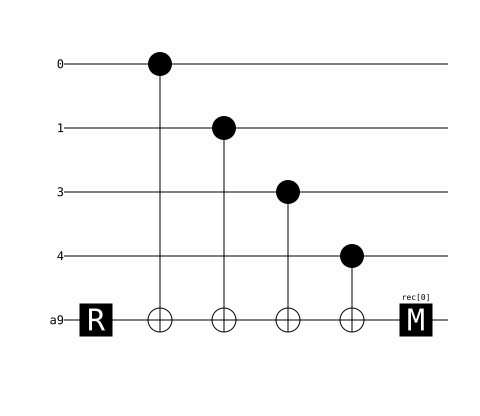

In [7]:
def measure_check(support, basis, ancilla=9):
    circuit = stim.Circuit()
    circuit.append("R", [ancilla])
    if basis == "X":
        circuit.append("H", [ancilla])
    circuit.append("TICK")
    for q in support:
        pair = [q, ancilla] if basis == "Z" else [ancilla, q]
        circuit.append("CX", pair)
        circuit.append("TICK")
    if basis == "X":
        circuit.append("H", [ancilla])
    circuit.append("M", [ancilla])
    return circuit


# Draw only the participating wires, retaining the physical labels.
from IPython.display import SVG
compact = measure_check(range(4), "Z", ancilla=4)
svg = str(compact.diagram("timeline-svg"))
for i, label in enumerate(["0", "1", "3", "4", "a9"]):
    svg = svg.replace(f">q{i}<", f">{label}<")
display(SVG(svg.replace("<svg ", '<svg width="480" ')))

An $X_0$ error should flip this $Z$ check. We can verify its ancilla readout on the same prepared logical state, both with and without that error.

In [8]:
for error in (stim.PauliString(9), pauli_on("X", [0])):
    sim = stim.TableauSimulator()
    sim.do(prepare_surface("0"))
    sim.do_pauli_string(error)
    sim.do(measure_check(z_supports[0], "Z"))
    bit = int(sim.current_measurement_record()[-1])
    expected = int(not error.commutes(stabilizers["SZ0"]))
    assert bit == expected
    print(f"Error {error}: ancilla bit {bit}, check sign {(-1)**bit:+d}")

Error +_________: ancilla bit 0, check sign +1
Error +X________: ancilla bit 1, check sign -1


### Measuring all eight checks

For a transparent first implementation, measure the checks **one after another**, reusing ancilla 9. This gives the syndrome in the fixed order $SX0,\ldots,SX3,SZ0,\ldots,SZ3$.

A full device instead uses multiple ancillas and interleaves the CNOTs. Gates in one time layer cannot share a qubit. The order must also preserve the joint measurements: two neighboring $X$ and $Z$ checks share two data qubits, and their interactions must have a consistent relative order at both. In the final experiment we use Stim's built-in scheduled circuit.

In [9]:
check_round = stim.Circuit()
for basis, supports in [("X", x_supports), ("Z", z_supports)]:
    for support in supports:
        check_round += measure_check(support, basis)


def syndrome_of(error):
    return tuple(int(not error.commutes(s)) for s in checks)


def measured_syndrome(error, state="0"):
    sim = stim.TableauSimulator()
    sim.do(prepare_surface(state))
    sim.do_pauli_string(error)
    sim.do(check_round)
    return tuple(map(int, sim.current_measurement_record()))


errors = {
    "None": stim.PauliString(9),
    "X4": pauli_on("X", [4]),
    "Z4": pauli_on("Z", [4]),
    "Y4": pauli_on("Y", [4]),
    "X0 X3": pauli_on("X", [0, 3]),
    "Logical X": logical_x,
}
print("Error       " + " ".join(stabilizers))
for label, error in errors.items():
    measured = measured_syndrome(error)
    assert measured == syndrome_of(error)
    print(f"{label:<12}" + "   ".join(map(str, measured)))

Error       SX0 SX1 SX2 SX3 SZ0 SZ1 SZ2 SZ3
None        0   0   0   0   0   0   0   0
X4          0   0   0   0   1   0   0   1
Z4          0   1   1   0   0   0   0   0
Y4          0   1   1   0   1   0   0   1
X0 X3       0   0   0   0   0   0   1   0
Logical X   0   0   0   0   0   0   0   0


## 4. Error strings and recovery

An $X$ error changes the signs of the $Z$ checks it anticommutes with; a $Z$ error changes $X$ checks. A $Y$ error can change both. Along an error string, two flips of the same check cancel, leaving the syndrome at the string's endpoints (or at the endpoint away from a suitable boundary).

In the figures, red data qubits carry $X$ errors and red check labels have sign $-1$. The completed column $X_0X_3X_6=\overline X$ has no syndrome at all, but flips the encoded logical $Z$ value.

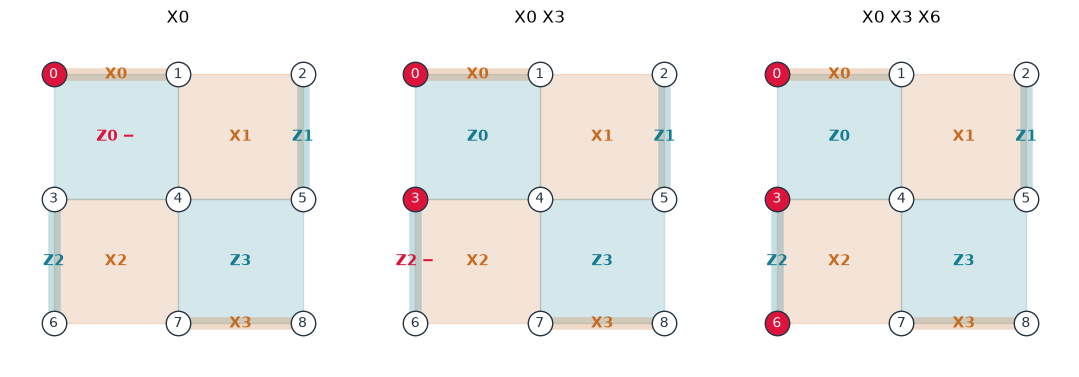

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.7))
for ax, support in zip(axes, [(0,), (0, 3), (0, 3, 6)]):
    draw_patch(ax, pauli_on("X", support), title=" ".join(f"X{q}" for q in support))
plt.tight_layout()
plt.show()

A decoder chooses a correction $C$ from the syndrome. Recovery succeeds when $CE$ is a stabilizer, up to phase, where $E$ is the actual error. Clearing the syndrome alone is insufficient: the remaining operator could be a logical $X$, $Y$, or $Z$.

For this nine-qubit example, we can reuse the Shor notebook's minimum-weight lookup method. The decoder chooses the first Pauli error of the smallest weight with the observed syndrome. This is an illustrative ideal-syndrome decoder, not the decoder we will use for repeated noisy measurements.

In [11]:
from itertools import combinations, product

recovery_table = {}
for weight in range(10):
    for qubits in combinations(range(9), weight):
        for letters in product("XYZ", repeat=weight):
            candidate = stim.PauliString(9)
            for q, letter in zip(qubits, letters):
                candidate[q] = letter
            recovery_table.setdefault(syndrome_of(candidate), candidate)
    if len(recovery_table) == 256:
        break
print(f"Covered all {len(recovery_table)} syndromes.")


def recovery_succeeds(error, correction):
    residual = correction * error
    return (not any(syndrome_of(residual))
            and residual.commutes(logical_x)
            and residual.commutes(logical_z))


for q in range(9):
    for letter in "XYZ":
        error = pauli_on(letter, [q])
        assert recovery_succeeds(error, recovery_table[syndrome_of(error)])
print("All 27 single-qubit Pauli errors are corrected.")

Covered all 256 syndromes.
All 27 single-qubit Pauli errors are corrected.


The two errors $X_0X_3$ and $X_6$ have the same syndrome because their product is $\overline X$. A decoder favoring a single-qubit error cannot correct both.

As before, we can record $C$ in a Pauli frame instead of applying it. The logical-$Z$ readout bit is flipped in software precisely when $C$ anticommutes with $\overline Z$. The next cell tests both the interpreted readout and the stronger condition that the full logical state is restored.

In [12]:
rows = ["| Error | Syndrome | Correction | Corrected Z bit | Logical state restored |",
        "|---|---|---|---|---|"]
for label, error in errors.items():
    syndrome = measured_syndrome(error)
    correction = recovery_table[syndrome]
    sim = stim.TableauSimulator()
    sim.do(prepare_surface("0"))
    sim.do_pauli_string(error)
    raw_bit = int(sim.measure_observable(logical_z))
    corrected = raw_bit ^ int(not correction.commutes(logical_z))
    rows.append(f"| {label} | {''.join(map(str, syndrome))} | `{correction}` "
                f"| {corrected} | {recovery_succeeds(error, correction)} |")
display(Markdown("\n".join(rows)))

| Error | Syndrome | Correction | Corrected Z bit | Logical state restored |
|---|---|---|---|---|
| None | 00000000 | `+_________` | 0 | True |
| X4 | 00001001 | `+____X____` | 0 | True |
| Z4 | 01100000 | `+____Z____` | 0 | True |
| Y4 | 01101001 | `+____Y____` | 0 | True |
| X0 X3 | 00000010 | `+______X__` | 1 | False |
| Logical X | 00000000 | `+_________` | 1 | False |

## 5. When a check readout is wrong

So far the measurement circuit has been ideal. A noisy readout can report the wrong sign even when the data has not changed. A single round cannot always distinguish these possibilities, so we repeat the checks.

For a check with reported bit $s(t)$ in round $t$, define a **detection event** by

$$
\delta(t)=s(t)\oplus s(t-1).
$$

Consider one check whose initial bit is known to be zero. A persistent data error changes its later signs until corrected; an isolated readout error changes one report. Their detection-event patterns differ:

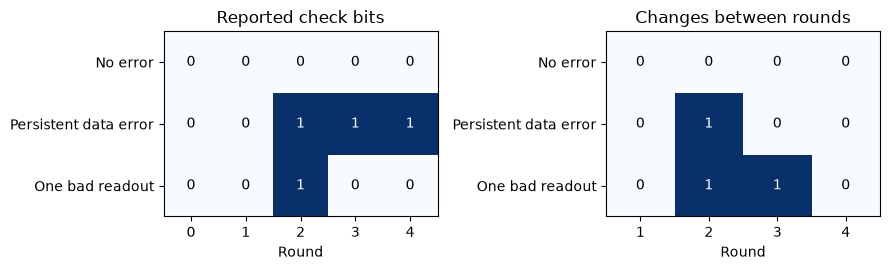

In [13]:
histories = {
    "No error": [0, 0, 0, 0, 0],
    "Persistent data error": [0, 0, 1, 1, 1],
    "One bad readout": [0, 0, 1, 0, 0],
}
fig, axes = plt.subplots(1, 2, figsize=(9, 2.8))
reports = np.array(list(histories.values()), dtype=int)
events = reports[:, 1:] ^ reports[:, :-1]
for ax, values, title, ticks in zip(axes, [reports, events],
        ["Reported check bits", "Changes between rounds"],
        [range(5), range(1, 5)]):
    ax.imshow(values, cmap="Blues", vmin=0, vmax=1, aspect="auto")
    for (row, col), value in np.ndenumerate(values):
        ax.text(col, row, str(value), ha="center", va="center",
                color="white" if value else "black")
    ax.set(xticks=range(len(ticks)), xticklabels=list(ticks),
           yticks=range(3), yticklabels=list(histories), xlabel="Round", title=title)
plt.tight_layout()
plt.show()

The persistent data error produces one change in this finite history; the bad readout produces two consecutive changes. This is a simplified trace of one check. A real data error can also trigger neighboring checks, and combinations of faults can produce ambiguous histories.

The first and last rounds need special treatment. Some initial check outcomes are random, so we cannot compare every first report with zero. At the end, data-qubit measurements supply a final parity to compare with the last compatible check report. These time boundaries are part of the decoder's information.

## 6. A memory experiment with noisy circuits

We now use Stim's `surface_code:rotated_memory_z` and `rotated_memory_x` circuits. They prepare a logical basis state by resetting the data and measuring local checks, repeat scheduled syndrome extraction, and finish with data readout in the matching basis. The generated detector definitions account for initialization and final readout.

For distance $d$, the patch uses $d^2$ data qubits and $d^2-1$ measurement ancillas. Stim assigns its own qubit IDs; the small helper below renumbers the data by rows, then assigns the ancillas the remaining IDs. For $d=3$, this matches the patch we used above. Measurement-record references are kept unchanged.

All four noise parameters below use the same probability $p$, at distinct locations:

- After each one-qubit Clifford gate, apply $X$, $Y$, or $Z$ with probability $p/3$ each. After a two-qubit Clifford gate, apply each of the 15 nonidentity two-qubit Pauli products with probability $p/15$.
- At the start of each syndrome round, apply independent depolarizing noise to the data with total probability $p$ per qubit.
- Flip a preparation result after reset, or flip a reported measurement result, with probability $p$ each, in the relevant basis.

Thus $p$ is a probability **per specified noise location**, not the probability that any error occurs anywhere in the experiment. This is a circuit noise model; it differs from the Shor notebook's single noisy storage interval.

Data: 9; ancillas: 8
Rounds: 3; detectors: 24; logical observables: 1


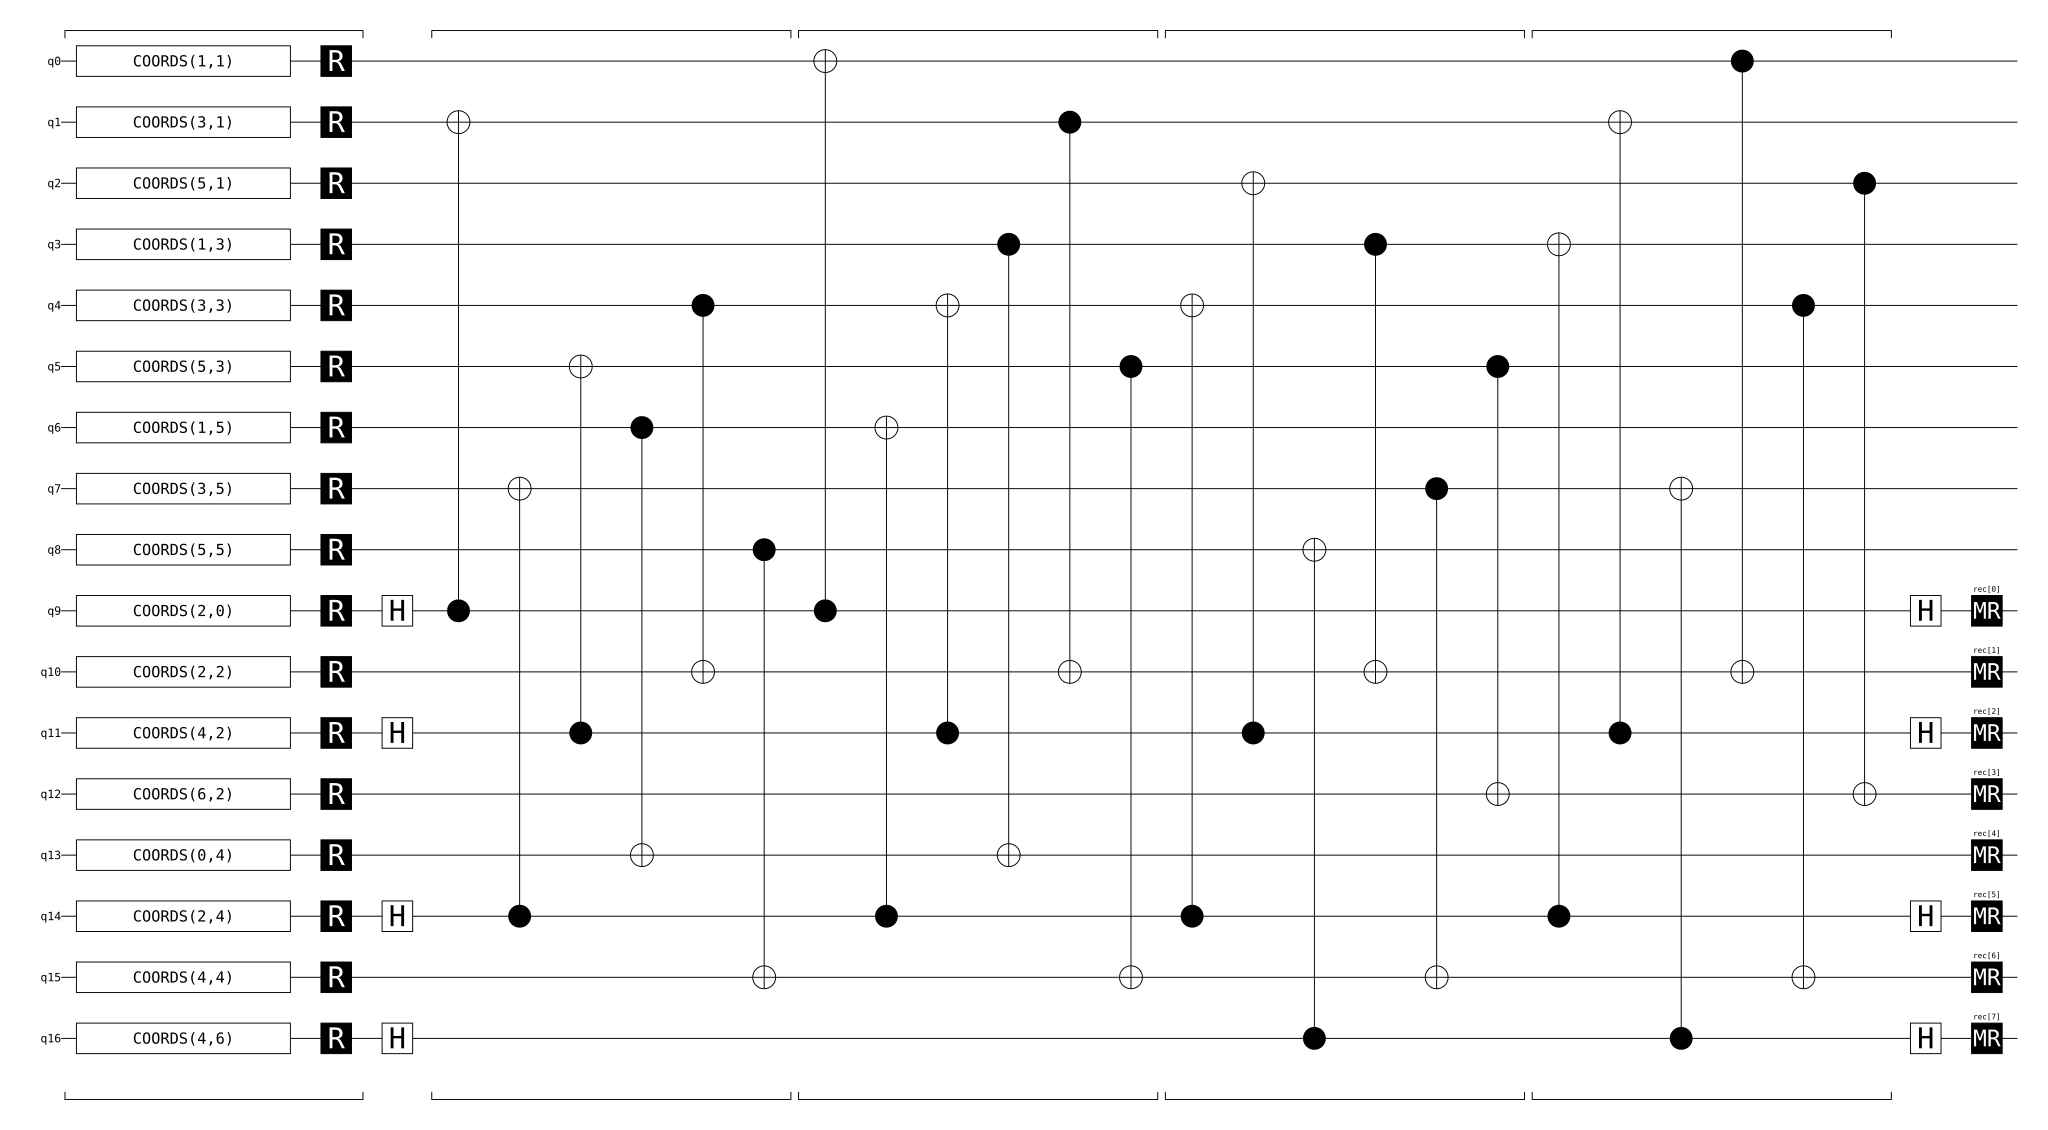

In [14]:
def memory_circuit(distance=3, rounds=5, p=0.0, basis="Z"):
    if basis not in ("X", "Z"):
        raise ValueError("Choose basis 'X' or 'Z'.")
    generated = stim.Circuit.generated(
        f"surface_code:rotated_memory_{basis.lower()}",
        distance=distance, rounds=rounds,
        after_clifford_depolarization=p,
        before_round_data_depolarization=p,
        before_measure_flip_probability=p,
        after_reset_flip_probability=p,
    )
    coords = generated.get_final_qubit_coordinates()
    # Odd x and y coordinates identify data qubits in this generator.
    data = [q for q, (x, y) in coords.items() if int(x) % 2 and int(y) % 2]
    order = sorted(data, key=lambda q: coords[q][::-1])
    order += sorted(set(coords) - set(data), key=lambda q: coords[q][::-1])
    labels = {q: i for i, q in enumerate(order)}
    circuit = stim.Circuit()
    for instruction in generated.flattened():
        targets = [labels[t.value] if t.is_qubit_target else t
                   for t in instruction.targets_copy()]
        circuit.append(instruction.name, targets, instruction.gate_args_copy())
    return circuit


ideal = memory_circuit(rounds=3)
print(f"Data: 9; ancillas: {ideal.num_qubits - 9}")
print(f"Rounds: 3; detectors: {ideal.num_detectors}; logical observables: {ideal.num_observables}")
# Show the beginning through the first ancilla readout.
first_round = stim.Circuit()
for instruction in ideal:
    first_round.append(instruction)
    if instruction.name == "MR":
        break
display(SVG(str(first_round.diagram("timeline-svg")).replace("<svg ", '<svg width="900" ')))

The ancillas interact with different data qubits in each CNOT layer, so checks run together without using a qubit twice in the same layer. The schedule is also chosen to control propagation of ancilla faults onto the data. A correlated data error caused by one ancilla fault is often called a **hook error**; its orientation matters for the circuit's error protection.

`MR` measures an ancilla in $Z$ and resets it for reuse. `TICK` separates time layers for description and drawing; it is not itself a noisy gate.

### From the measurement record to detector bits

`DETECTOR` declares a parity of measurement results that is predictable without noise. It does not add a physical measurement. A sampled detector bit is one when that parity differs from its noiseless reference. `OBSERVABLE_INCLUDE(0)` declares the measurement parity used for logical readout.

Stim's `rec[-1]` means the most recent measurement result, `rec[-2]` the preceding result, and so on. The next cell prints a few detector definitions and checks that an ideal experiment has no detection events or logical readout flips. The individual ancilla outcomes need not all be zero.

In [15]:
detector_lines = [str(inst) for inst in ideal if inst.name == "DETECTOR"]
print("First-round detectors:")
print("\n".join(detector_lines[:4]))
print("First comparison between rounds:")
print(detector_lines[4])
print("Logical readout:")
print(next(str(inst) for inst in ideal if inst.name == "OBSERVABLE_INCLUDE"))

for basis in ("Z", "X"):
    clean = memory_circuit(basis=basis)
    events, logical_flips = clean.compile_detector_sampler(seed=7).sample(
        shots=100, separate_observables=True)
    assert not events.any() and not logical_flips.any()
print("Both ideal memory experiments: no detection events or logical flips.")

First-round detectors:
DETECTOR(0, 4, 0) rec[-4]
DETECTOR(2, 2, 0) rec[-7]
DETECTOR(4, 4, 0) rec[-2]
DETECTOR(6, 2, 0) rec[-5]
First comparison between rounds:
DETECTOR(2, 0, 1) rec[-8] rec[-16]
Logical readout:
OBSERVABLE_INCLUDE(0) rec[-7] rec[-8] rec[-9]
Both ideal memory experiments: no detection events or logical flips.


### Decoding the history

A **detector error model** describes which detector bits and logical parities are flipped by faults in the circuit. PyMatching turns its graphlike components into a matching graph: detection events are vertices, possible fault connections are edges, and edge weights reflect their probabilities.

The decoder sees the detector bits and predicts whether the logical readout needs flipping. If its prediction disagrees with the sampled logical flip, the corrected readout is wrong. The sampled logical flip is used only to score the decoder, never as its input.

We use ordinary minimum-weight matching. Decomposing multi-detector faults lets us use that decoder, but this does not make it an exact maximum-likelihood decoder for correlated circuit noise.

In [16]:
import pymatching


def run_memory(distance, rounds, p, basis, shots=20_000, seed=0):
    circuit = memory_circuit(distance, rounds, p, basis)
    model = circuit.detector_error_model(decompose_errors=True)
    decoder = pymatching.Matching.from_detector_error_model(model)
    events, actual_flips = circuit.compile_detector_sampler(seed=seed).sample(
        shots=shots, separate_observables=True)
    predicted_flips = decoder.decode_batch(events)
    failures = np.any(predicted_flips != actual_flips, axis=1)
    return int(failures.sum())


shots = 20_000
rounds = 5  # Keep the storage duration equal when comparing distances.
physical_rates = [0.001, 0.003, 0.006, 0.01, 0.02]
results = []
for b, basis in enumerate(("Z", "X")):
    for distance in (3, 5):
        for i, p in enumerate(physical_rates):
            failures = run_memory(distance, rounds, p, basis, shots,
                                  seed=1000 + 100*b + 10*distance + i)
            results.append((basis, distance, p, failures, shots))
print(f"Completed {len(results)} experiments, {shots:,} shots each.")

Completed 20 experiments, 20,000 shots each.


For each experiment, estimate the logical readout failure probability by $\hat p_L=k/N$, where $k$ failures occurred in $N$ shots. We plot 95% Wilson intervals to show sampling uncertainty, on logarithmic axes. If a rerun observes zero failures, a downward marker shows a one-sided 95% upper bound instead of a point at zero.

The two panels test different logical information: a $Z$-basis memory detects residual logical $X$ or $Y$ errors, while an $X$-basis memory detects residual logical $Z$ or $Y$ errors. Neither panel alone gives the probability of any logical error.

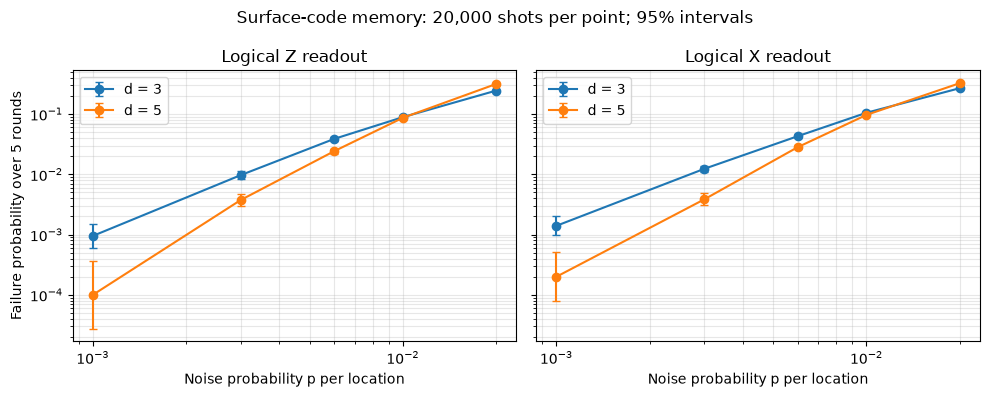

| Basis | Distance | p | Failures / shots | Estimated failure |
|---|---|---|---|---|
| Z | 3 | 0.001 | 19 / 20000 | 0.095% |
| Z | 3 | 0.003 | 194 / 20000 | 0.970% |
| Z | 3 | 0.006 | 773 / 20000 | 3.865% |
| Z | 3 | 0.010 | 1777 / 20000 | 8.885% |
| Z | 3 | 0.020 | 4901 / 20000 | 24.505% |
| Z | 5 | 0.001 | 2 / 20000 | 0.010% |
| Z | 5 | 0.003 | 75 / 20000 | 0.375% |
| Z | 5 | 0.006 | 483 / 20000 | 2.415% |
| Z | 5 | 0.010 | 1733 / 20000 | 8.665% |
| Z | 5 | 0.020 | 6316 / 20000 | 31.580% |
| X | 3 | 0.001 | 28 / 20000 | 0.140% |
| X | 3 | 0.003 | 247 / 20000 | 1.235% |
| X | 3 | 0.006 | 858 / 20000 | 4.290% |
| X | 3 | 0.010 | 2101 / 20000 | 10.505% |
| X | 3 | 0.020 | 5374 / 20000 | 26.870% |
| X | 5 | 0.001 | 4 / 20000 | 0.020% |
| X | 5 | 0.003 | 77 / 20000 | 0.385% |
| X | 5 | 0.006 | 564 / 20000 | 2.820% |
| X | 5 | 0.010 | 1936 / 20000 | 9.680% |
| X | 5 | 0.020 | 6508 / 20000 | 32.540% |

In [17]:
def wilson_interval(failures, shots):
    rate = failures / shots
    z = 1.96
    denominator = 1 + z*z/shots
    center = (rate + z*z/(2*shots)) / denominator
    half = z * np.sqrt(rate*(1-rate)/shots + z*z/(4*shots*shots)) / denominator
    return max(0, center-half), min(1, center+half)


fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, basis in zip(axes, ("Z", "X")):
    for distance in (3, 5):
        subset = [r for r in results if r[0] == basis and r[1] == distance]
        ps = np.array([r[2] for r in subset])
        rates = np.array([r[3]/r[4] for r in subset])
        intervals = np.array([wilson_interval(r[3], r[4]) for r in subset])
        positive = rates > 0
        ax.errorbar(ps[positive], rates[positive],
                    yerr=[rates[positive]-intervals[positive, 0],
                          intervals[positive, 1]-rates[positive]],
                    fmt="o-", capsize=3, label=f"d = {distance}")
        if (~positive).any():
            # One-sided 95% upper limit when zero failures were observed.
            upper = 1 - 0.05**(1/shots)
            ax.errorbar(ps[~positive], np.full((~positive).sum(), upper),
                        yerr=upper/3, uplims=True, fmt="v", color="gray")
    ax.set(xlabel="Noise probability p per location", title=f"Logical {basis} readout")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(alpha=0.3, which="both")
    ax.legend()
axes[0].set_ylabel("Failure probability over 5 rounds")
fig.suptitle(f"Surface-code memory: {shots:,} shots per point; 95% intervals")
plt.tight_layout()
plt.show()

rows = ["| Basis | Distance | p | Failures / shots | Estimated failure |",
        "|---|---|---|---|---|"]
for basis, d, p, k, n in results:
    rows.append(f"| {basis} | {d} | {p:.3f} | {k} / {n} | {k/n:.3%} |")
display(Markdown("\n".join(rows)))

At sufficiently low physical noise, a larger patch can reduce the logical failure probability despite using more qubits and gates. The plotted estimates test that behavior for this specific schedule, noise model, decoder, and five-round duration. Two distances and a small sweep do not establish an asymptotic threshold.

## 7. Joining patches to measure a joint parity

To compute with stored qubits, we need operations between logical patches. **Lattice surgery** changes local checks near a shared boundary to measure a joint logical operator, then separates the patches again.

For two patches $L$ and $R$, measuring $P=\overline Z_L\overline Z_R$ tells us whether their logical $Z$ values agree. It does not identify each value. For example, a $+1$ result retains both $|00\rangle_L$ and $|11\rangle_L$, and can leave a superposition of them. Measuring the two logical $Z$ operators separately would distinguish those two terms.

### A seam we can inspect

Place patch $L$ above $R$, with three bridge data qubits between their facing edges. Choose logical representatives along those edges:

$$
\overline Z_L=Z_{L_6}Z_{L_7}Z_{L_8},\qquad
\overline Z_R=Z_{R_0}Z_{R_1}Z_{R_2}.
$$

The bottom-edge representative on $L$ differs from its top-edge representative only by a product of stabilizers. Label the bridge qubits $b_2,b_1,b_0$ from left to right and prepare them in $|+\rangle$. Measure four new $Z$ checks:

$$
\begin{aligned}
G_1&=Z_{L_8}Z_{b_0},\\
G_2&=Z_{b_0}Z_{b_1}Z_{R_2}Z_{R_1},\\
G_3&=Z_{L_7}Z_{L_6}Z_{b_1}Z_{b_2},\\
G_4&=Z_{b_2}Z_{R_0}.
\end{aligned}
$$

Each bridge $Z$ occurs twice in their product and cancels, since $Z^2=I$. Therefore

$$G_1G_2G_3G_4=P,\qquad m=g_1\oplus g_2\oplus g_3\oplus g_4,$$

where check $G_j$ has measured sign $(-1)^{g_j}$ and the joint logical result is $(-1)^m$.

Two old boundary checks must also change. Replace $X_{L_7}X_{L_8}$ and $X_{R_0}X_{R_1}$ with

$$
H_L=X_{L_7}X_{L_8}X_{b_0}X_{b_1},\qquad
H_R=X_{b_1}X_{b_2}X_{R_0}X_{R_1}.
$$

The old checks anticommute with individual seam checks; measuring them would randomize those seam signs. The extended checks commute with every $G_j$. Together with the retained checks they define the merged code. This example uses ideal Pauli-product measurements to make the measurement algebra explicit; it is not yet a scheduled noisy seam circuit.

In [18]:
# One Stim register: L0–L8 = 0–8, R0–R8 = 9–17, b0–b2 = 18–20.
L = list(range(9))
R = list(range(9, 18))
b = [18, 19, 20]


def seam_pauli(letter, qubits):
    operator = stim.PauliString(21)
    for q in qubits:
        operator[q] = letter
    return operator


def on_patch(operator, patch):
    embedded = stim.PauliString(21)
    for q in range(9):
        embedded[patch[q]] = operator[q]
    embedded.sign = operator.sign
    return embedded


left_checks = [on_patch(s, L) for s in checks]
right_checks = [on_patch(s, R) for s in checks]
G = [seam_pauli("Z", qs) for qs in
     [(L[8], b[0]), (b[0], b[1], R[2], R[1]),
      (L[7], L[6], b[1], b[2]), (b[2], R[0])]]
H_left = seam_pauli("X", [L[7], L[8], b[0], b[1]])
H_right = seam_pauli("X", [b[1], b[2], R[0], R[1]])
Z_left = seam_pauli("Z", [L[6], L[7], L[8]])
Z_right = on_patch(logical_z, R)
X_left, X_right = on_patch(logical_x, L), on_patch(logical_x, R)
P = Z_left * Z_right
assert G[0] * G[1] * G[2] * G[3] == P
# Replace SX3 on L and SX0 on R; retain every other old check.
merged_checks = ([s for i, s in enumerate(left_checks) if i != 3]
                 + [s for i, s in enumerate(right_checks) if i != 0]
                 + [H_left, H_right] + G)
assert all(a.commutes(c) for a in merged_checks for c in merged_checks)
print("Seam product equals logical ZZ; all merged checks commute.")

Seam product equals logical ZZ; all merged checks commute.


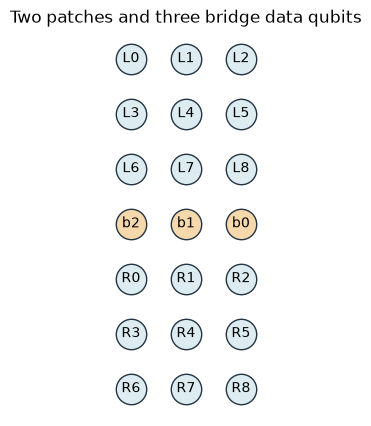

In [19]:
fig, ax = plt.subplots(figsize=(5, 5))
for patch, y_shift, prefix in [(L, 0, "L"), (R, 4, "R")]:
    for i, q in enumerate(patch):
        x, y = i % 3, i // 3 + y_shift
        ax.scatter(x, y, s=480, color="#dcecf0", edgecolor="#253443")
        ax.text(x, y, f"{prefix}{i}", ha="center", va="center", fontsize=10)
for i in range(3):
    ax.scatter(2-i, 3, s=480, color="#f5d8ab", edgecolor="#253443")
    ax.text(2-i, 3, f"b{i}", ha="center", va="center", fontsize=10)
ax.set(xlim=(-0.6, 2.6), ylim=(6.5, -0.5), aspect="equal",
       title="Two patches and three bridge data qubits")
ax.axis("off")
plt.show()

### Split and interpret the outcomes

Measure the bridges in $X$ to separate the patches. Let $r_i=0$ mean the $+1$ result and $r_i=1$ mean the $-1$ result on $b_i$. The restored boundary checks have signs $(-1)^{r_0\oplus r_1}$ on $L$ and $(-1)^{r_1\oplus r_2}$ on $R$.

The bridge readout also changes the relative signs of some data-state amplitudes: an $X$-basis outcome $r$ contributes $\langle r_X|\beta\rangle=(-1)^{r\beta}/\sqrt2$ to a bridge computational-basis value $\beta$. Substituting the bridge values fixed by the seam outcomes gives the correction

$$
D_{\mathbf r}=
Z_{L_8}^{r_0\oplus r_1}
Z_{R_0}^{r_1\oplus r_2}
\overline Z_R^{r_1}.
$$

The first two factors restore the local boundary-check signs; the last accounts for the logical phase. We can track this Pauli correction in a frame. In the ideal simulation below we apply it explicitly so that its effect on the final state is easy to inspect.

Starting with $|+_L\rangle|+_L\rangle$, the corrected output should retain $X_LX_R=+1$, acquire $Z_LZ_R=(-1)^m$, and have no definite individual logical $Z$ value. These correlations identify a Bell state on the logical qubits.

In [20]:
initial_stabilizers = (left_checks + right_checks + [X_left, X_right]
                       + [seam_pauli("X", [q]) for q in b])
seam_initial = stim.Tableau.from_stabilizers(initial_stabilizers).to_circuit()
rows = ["| Seam bits g | Joint bit m | Bridge bits r | <ZL ZR> | <XL XR> | <ZL>, <ZR> |",
        "|---|---|---|---|---|---|"]
for seed in range(8):
    sim = stim.TableauSimulator(seed=seed)
    sim.do(seam_initial)
    g = [int(sim.measure_observable(op)) for op in G]
    m = int(np.bitwise_xor.reduce(g))
    r = [int(sim.measure_observable(seam_pauli("X", [q]))) for q in b]
    frame = stim.PauliString(21)
    if r[0] ^ r[1]:
        frame *= seam_pauli("Z", [L[8]])
    if r[1] ^ r[2]:
        frame *= seam_pauli("Z", [R[0]])
    if r[1]:
        frame *= Z_right
    sim.do_pauli_string(frame)
    zz = sim.peek_observable_expectation(P)
    xx = sim.peek_observable_expectation(X_left * X_right)
    zl, zr = [sim.peek_observable_expectation(z) for z in [Z_left, Z_right]]
    assert all(sim.peek_observable_expectation(s) == 1 for s in left_checks + right_checks)
    assert zz == (-1)**m and xx == 1 and zl == zr == 0
    rows.append(f"| {g} | {m} | {r} | {zz:+d} | {xx:+d} | {zl}, {zr} |")
display(Markdown("\n".join(rows)))

| Seam bits g | Joint bit m | Bridge bits r | <ZL ZR> | <XL XR> | <ZL>, <ZR> |
|---|---|---|---|---|---|
| [0, 1, 0, 0] | 1 | [0, 1, 1] | -1 | +1 | 0, 0 |
| [1, 1, 1, 1] | 0 | [1, 1, 1] | +1 | +1 | 0, 0 |
| [1, 0, 0, 0] | 1 | [1, 0, 0] | -1 | +1 | 0, 0 |
| [0, 1, 0, 1] | 0 | [0, 1, 1] | +1 | +1 | 0, 0 |
| [1, 0, 1, 1] | 1 | [1, 1, 0] | -1 | +1 | 0, 0 |
| [0, 1, 1, 0] | 0 | [1, 1, 0] | +1 | +1 | 0, 0 |
| [1, 1, 1, 0] | 1 | [0, 1, 0] | -1 | +1 | 0, 0 |
| [1, 0, 1, 1] | 1 | [1, 0, 0] | -1 | +1 | 0, 0 |

Exchanging $X$ and $Z$ gives a joint $XX$ measurement on compatible edges. A mixed $ZX$ parity can be understood by changing one patch's logical basis: $H_R(Z_LZ_R)H_R=Z_LX_R$. A physical implementation must also arrange the appropriate boundaries; inserting a symbolic $H_R$ alone does not specify a surgery schedule.

## 8. Building CNOT from joint measurements

Use control $C$, auxiliary logical qubit $A$ prepared in $|+_L\rangle$, and target $T$. Measure, in this order:

1. $Z_CZ_A$, with result bit $a$.
2. $X_AX_T$, with result bit $b$.
3. $Z_A$, with result bit $c$; the auxiliary can then be reset for reuse.

Here $X$ and $Z$ denote **logical** operators and each bit denotes sign $(-1)^{\text{bit}}$. Account for the correction

$$F=Z_C^b X_T^{a\oplus c}.$$

Each parity measurement already includes its own merge-and-split corrections. The extra $F$ comes from the three-measurement CNOT protocol.

To see the CNOT action, track the input Paulis. Initially $X_A=+1$, so $X_C$ can be represented as $X_CX_A$. This commutes through both joint measurements. Once $X_AX_T=(-1)^b$, it becomes $(-1)^bX_CX_T$, which also commutes with the final auxiliary readout.

For $Z_T$, use the first outcome $Z_CZ_A=(-1)^a$ to choose the equivalent representative $(-1)^a Z_CZ_AZ_T$. It commutes with $X_AX_T$ through two anticommutations. The final result $Z_A=(-1)^c$ leaves $(-1)^{a\oplus c}Z_CZ_T$. The other two input Paulis commute throughout. After accounting for $F$, we obtain

$$
X_C\mapsto X_CX_T,\quad Z_C\mapsto Z_C,\quad
X_T\mapsto X_T,\quad Z_T\mapsto Z_CZ_T,
$$

which are the Pauli transformations of CNOT.

### Check every outcome branch

We can verify the same identity with small matrices acting on the three **logical** qubits. For result $a$, the $ZZ$ projector is $(I+(-1)^aZ_CZ_A)/2$, and similarly for $XX$. Removing the measured auxiliary with $\langle c|_A$ gives a two-qubit branch operator $K_{abc}$. We check

$$F K_{abc}=\frac{(-1)^{b(a\oplus c)}}{2\sqrt2}\,\mathrm{CNOT}_{C\to T}.$$

This tests the full linear operator, so it covers arbitrary superpositions, not just a classical truth table. The scalar also shows that each outcome branch has probability $1/8$.

In [21]:
I = np.eye(2)
X = np.array([[0, 1], [1, 0]])
Z = np.diag([1, -1])
plus = np.array([1, 1]) / np.sqrt(2)
ZZ = np.kron(np.kron(Z, Z), I)  # Register order C, A, T.
XX = np.kron(np.kron(I, X), X)

# Embed a two-qubit C,T input with |+> on A.
embed = np.column_stack([
    np.kron(np.kron(I[:, x], plus), I[:, y])
    for x in range(2) for y in range(2)
])
cnot = np.zeros((4, 4))
for x in range(2):
    for y in range(2):
        cnot[2*x + (y ^ x), 2*x + y] = 1

for a, b_bit, c in product(range(2), repeat=3):
    project_zz = (np.eye(8) + (-1)**a * ZZ) / 2
    project_xx = (np.eye(8) + (-1)**b_bit * XX) / 2
    branch = (project_xx @ project_zz @ embed).reshape(2, 2, 2, 4)[:, c, :, :].reshape(4, 4)
    frame = np.kron(np.linalg.matrix_power(Z, b_bit), np.linalg.matrix_power(X, a ^ c))
    expected = (-1)**(b_bit * (a ^ c)) * cnot / np.sqrt(8)
    np.testing.assert_allclose(frame @ branch, expected, atol=1e-12)
print("All eight branches implement CNOT after the known Pauli correction.")

All eight branches implement CNOT after the known Pauli correction.


## 9. A physical lattice-surgery circuit with Loom

The previous calculation describes logical measurements. **Loom** lets us build a circuit from patches and local operations. We use its installed `RotatedSurfaceCode` factory and `AuxCNOT` operation, then convert the result to Stim.

The factory defines its own coordinates, logical representatives, and measurement schedule. We use those definitions consistently throughout this example; its qubit labels are not the 0–8 labels from the earlier single-patch circuit.

A `Block` describes a patch. An `Eka` contains the lattice, blocks, and operation sequence. `interpret_eka` expands that sequence into physical operations. Loom's `AuxCNOT` uses a grow/split/merge/shrink construction with an auxiliary patch. It is a physical implementation of a logical CNOT, not a literal reuse of the four seam checks above.

We keep this final experiment noiseless: it demonstrates the logical action and geometry. A noisy CNOT performance study would additionally require decoding its complete detector history.

In [22]:
from loom.eka import Eka, Lattice
from loom.eka.operations import (ResetAllDataQubits, MeasureBlockSyndromes,
                                 MeasureLogicalZ, MeasureLogicalX)
from loom.interpreter import interpret_eka
from loom.executor import EkaToStimConverter
from loom_rotated_surface_code.code_factory import RotatedSurfaceCode
from loom_rotated_surface_code.operations import AuxCNOT

print("Loom version:", version("el-loom"))
surgery_distance = 3
surgery_lattice = Lattice.square_2d((8, 8))
control_block = RotatedSurfaceCode.create(3, 3, surgery_lattice, unique_label="control")
# Offset both coordinates by d+1 to leave room for the auxiliary patch.
target_block = control_block.shift((4, 4)).rename("target")


def make_cnot_experiment(control_state, target_state, basis):
    readout = MeasureLogicalZ if basis == "Z" else MeasureLogicalX
    operations = (
        (ResetAllDataQubits("control", state=control_state),
         ResetAllDataQubits("target", state=target_state)),
        (MeasureBlockSyndromes("control", n_cycles=surgery_distance),
         MeasureBlockSyndromes("target", n_cycles=surgery_distance)),
        (AuxCNOT(("control", "target")),),
        (readout("control"), readout("target")),
    )
    return interpret_eka(Eka(surgery_lattice, (control_block, target_block), operations),
                         debug_mode=False)


surgery = make_cnot_experiment("+", "0", "Z")
compiled, _, _ = EkaToStimConverter().convert(surgery, with_ticks=True)
print(f"Physical circuit: {compiled.num_qubits} indexed qubits, "
      f"{compiled.num_measurements} measurements, {compiled.num_detectors} detectors.")

Loom version: 0.4.0


Physical circuit: 65 indexed qubits, 273 measurements, 232 detectors.


The plot shows the changes in **data-qubit geometry**. Growing and splitting the control creates a correlated auxiliary patch; merging that auxiliary with the target transfers the required parity information. After shrinking, two separate output patches remain. Measurement ancillas and individual gates are omitted from this overview.

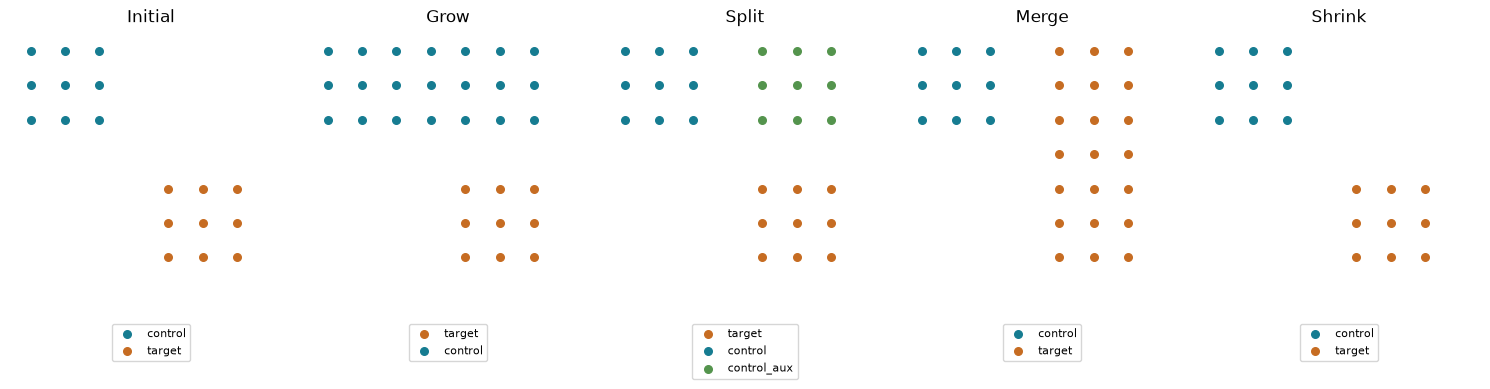

In [23]:
stages = []
last_geometry = None
for timestamp, ids in surgery.block_history.blocks_over_time():
    blocks = [surgery.block_registry[i] for i in ids]
    geometry = tuple(sorted((block.unique_label, tuple(block.size)) for block in blocks))
    if geometry != last_geometry:
        stages.append((timestamp, blocks))
        last_geometry = geometry

fig, axes = plt.subplots(1, len(stages), figsize=(3*len(stages), 3.5), squeeze=False)
stage_names = ["Initial", "Grow", "Split", "Merge", "Shrink"]
colors = {"control": "#167c91", "target": "#c66c22", "control_aux": "#54944d"}
for ax, name, (timestamp, blocks) in zip(axes[0], stage_names, stages):
    for block in blocks:
        coords = np.array(list(block.data_qubits))
        ax.scatter(coords[:, 0], coords[:, 1], s=30, color=colors[block.unique_label], label=block.unique_label)
    ax.set(title=name, aspect="equal", xlim=(-0.6, 7.6), ylim=(7.6, -0.6))
    ax.axis("off")
    ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()

### Test the logical output

For computational-basis inputs, CNOT maps $(x,y)$ to $(x,y\oplus x)$. We test all four inputs. We also test $|+\rangle_C|0\rangle_T$, which should produce the Bell state $(|00\rangle+|11\rangle)/\sqrt2$: both $Z$-basis and $X$-basis readouts should agree, while either individual result is random.

The final logical bits are parities of physical measurement records. Loom's logical-observable definitions include its internal outcome-dependent frame updates; computing these parities is how we account for those corrections. We read **raw records** here because detector-sampler outputs describe flips relative to a reference, rather than the actual logical values 0 and 1.

In [24]:
def logical_samples(step, shots=256, seed=0):
    converter = EkaToStimConverter()
    circuit, _, classical_map = converter.convert(step)
    raw = circuit.compile_sampler(seed=seed).sample(shots=shots)
    records = converter.parse_target_run_outcome((raw, classical_map))
    logical_bits = []
    for observable in step.logical_observables:
        terms = [records[f"{label}_{round_number}"]
                 for label, round_number in observable.measurements]
        logical_bits.append(np.bitwise_xor.reduce(terms, axis=0).astype(int))
    return np.array(logical_bits).T


for x, y in product(range(2), repeat=2):
    step = make_cnot_experiment(str(x), str(y), "Z")
    bits = logical_samples(step, seed=10 + 2*x + y)
    assert np.all(bits == [x, y ^ x])
    print(f"|{x}{y}> → |{x}{y ^ x}>: all shots agree")

for i, basis in enumerate(("Z", "X")):
    step = make_cnot_experiment("+", "0", basis)
    bits = logical_samples(step, shots=512, seed=30+i)
    assert np.all(bits[:, 0] == bits[:, 1])
    outcomes, counts = np.unique(bits, axis=0, return_counts=True)
    print(f"Bell state in {basis}:", {"".join(map(str, v)): int(n) for v, n in zip(outcomes, counts)})

|00> → |00>: all shots agree


|01> → |01>: all shots agree
|10> → |11>: all shots agree
|11> → |10>: all shots agree


Bell state in Z: {'00': 250, '11': 262}
Bell state in X: {'00': 260, '11': 252}


The basis-state tests check the classical truth table, and the Bell-state tests check complementary correlations. Together they provide concrete checks of this compiled example; they are not an exhaustive proof of noisy fault tolerance. The earlier branch-operator identity establishes the ideal measurement protocol's action on arbitrary logical inputs.

A surface-code memory repeatedly measures local checks to protect information. Lattice surgery changes those checks temporarily so that the same measurement machinery can act on the logical information as well.

References used for the implementations and conventions:

- [Stim](https://github.com/quantumlib/Stim): stabilizer simulation and generated memory circuits.
- [PyMatching's Stim example](https://github.com/oscarhiggott/PyMatching#decoding-stim-circuits): detector models and batch decoding.
- [Loom Design](https://loom-docs.entropicalabs.com/): patches, interpretation, and lattice-surgery operations.
- [Fowler et al., *Surface codes: Towards practical large-scale quantum computation*](https://arxiv.org/abs/1208.0928): surface-code background.
- [Horsman et al., *Surface code quantum computing by lattice surgery*](https://arxiv.org/abs/1111.4022): merge-and-split logical operations.